### Predictive Modeling with Random Forest Regression

By Stephanie Nguyen

### A1: PROPOSAL QUESTION

How accurately can we predict the length of hospital stay based on patient demographic information and medical conditions using Random Forest Regression?

### A2: DEFINED GOAL

GOAL: Use Random Forest Regression to develop an accurate predictive model that can estimate the duration of a patient's hospital stay based on their medical data.

### B1: EXPLANATION OF PREDICTION METHOD

Given the continuous nature of the output variable, Random Forest Regression was used to predict the target variable. 

### B2: SUMMARY OF METHOD ASSUMPTION
ASSUMPTION: Bootstrap samples are representative of the overall dataset 

### B3: PACKAGES OR LIBRARIES LIST

In [ ]:
# Importing all libraries and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# train/test split, hyperparameter tuning
from sklearn.model_selection import train_test_split, GridSearchCV

# Random Forest Regression
from sklearn.ensemble import RandomForestRegressor

# model scoring function used in GridSearchCV, coefficient of determination(R-squared)
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import make_scorer, r2_score

In [ ]:
# Load Data
# import medical_clean.csv data set
df = pd.read_csv(r"C:\Users\steph\Documents\GitHub\Data Analysis\7. Data Mining with Random Forest in Python\Data\medical_clean.csv")

# FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To opt-in to the future behavior, set
pd.set_option('future.no_silent_downcasting', True)

### C1: DATA PREPROCESSING

In [ ]:
# Get the number of rows and columns in the dataframe
df.shape

(10000, 50)

In [ ]:
# preview the data
pd.set_option('display.max_columns',None)
df.head()

,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,Population,Area,TimeZone,Job,Children,Age,Income,Marital,Gender,ReAdmis,VitD_levels,Doc_visits,Full_meals_eaten,vitD_supp,Soft_drink,Initial_admin,HighBlood,Stroke,Complication_risk,Overweight,Arthritis,Diabetes,Hyperlipidemia,BackPain,Anxiety,Allergic_rhinitis,Reflux_esophagitis,Asthma,Services,Initial_days,TotalCharge,Additional_charges,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8
0,1,C412403,8cd49b13-f45a-4b47-a2bd-173ffa932c2f,3a83ddb66e2ae73798bdf1d705dc0932,Eva,AL,Morgan,35621,34.34960,-86.72508,2951,Suburban,America/Chicago,"Psychologist, sport and exercise",1,53,86575.93,Divorced,Male,No,19.141466,6,0,0,No,Emergency Admission,Yes,No,Medium,No,Yes,Yes,No,Yes,Yes,Yes,No,Yes,Blood Work,10.585770,3726.702860,17939.403420,3,3,2,2,4,3,3,4
1,2,Z919181,d2450b70-0337-4406-bdbb-bc1037f1734c,176354c5eef714957d486009feabf195,Marianna,FL,Jackson,32446,30.84513,-85.22907,11303,Urban,America/Chicago,Community development worker,3,51,46805.99,Married,Female,No,18.940352,4,2,1,No,Emergency Admission,Yes,No,High,Yes,No,No,No,No,No,No,Yes,No,Intravenous,15.129562,4193.190458,17612.998120,3,4,3,4,4,4,3,3
2,3,F995323,a2057123-abf5-4a2c-abad-8ffe33512562,e19a0fa00aeda885b8a436757e889bc9,Sioux Falls,SD,Minnehaha,57110,43.54321,-96.63772,17125,Suburban,America/Chicago,Chief Executive Officer,3,53,14370.14,Widowed,Female,No,18.057507,4,1,0,No,Elective Admission,Yes,No,Medium,Yes,No,Yes,No,No,No,No,No,No,Blood Work,4.772177,2434.234222,17505.192460,2,4,4,4,3,4,3,3
3,4,A879973,1dec528d-eb34-4079-adce-0d7a40e82205,cd17d7b6d152cb6f23957346d11c3f07,New Richland,MN,Waseca,56072,43.89744,-93.51479,2162,Suburban,America/Chicago,Early years teacher,0,78,39741.49,Married,Male,No,16.576858,4,1,0,No,Elective Admission,No,Yes,Medium,No,Yes,No,No,No,No,No,Yes,Yes,Blood Work,1.714879,2127.830423,12993.437350,3,5,5,3,4,5,5,5
4,5,C544523,5885f56b-d6da-43a3-8760-83583af94266,d2f0425877b10ed6bb381f3e2579424a,West Point,VA,King William,23181,37.59894,-76.88958,5287,Rural,America/New_York,Health promotion specialist,1,22,1209.56,Widowed,Female,No,17.439069,5,0,2,Yes,Elective Admission,No,No,Low,No,No,No,Yes,No,No,Yes,No,No,CT Scan,1.254807,2113.073274,3716.525786,2,1,3,3,5,3,4,3


In [ ]:
# get overview of columns and data types in dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CaseOrder           10000 non-null  int64  
 1   Customer_id         10000 non-null  object 
 2   Interaction         10000 non-null  object 
 3   UID                 10000 non-null  object 
 4   City                10000 non-null  object 
 5   State               10000 non-null  object 
 6   County              10000 non-null  object 
 7   Zip                 10000 non-null  int64  
 8   Lat                 10000 non-null  float64
 9   Lng                 10000 non-null  float64
 10  Population          10000 non-null  int64  
 11  Area                10000 non-null  object 
 12  TimeZone            10000 non-null  object 
 13  Job                 10000 non-null  object 
 14  Children            10000 non-null  int64  
 15  Age                 10000 non-null  int64  
 16  Incom

In [ ]:
# detect null values
df.isnull().sum()

CaseOrder             0
Customer_id           0
Interaction           0
UID                   0
City                  0
State                 0
County                0
Zip                   0
Lat                   0
Lng                   0
Population            0
Area                  0
TimeZone              0
Job                   0
Children              0
Age                   0
Income                0
Marital               0
Gender                0
ReAdmis               0
VitD_levels           0
Doc_visits            0
Full_meals_eaten      0
vitD_supp             0
Soft_drink            0
Initial_admin         0
HighBlood             0
Stroke                0
Complication_risk     0
Overweight            0
Arthritis             0
Diabetes              0
Hyperlipidemia        0
BackPain              0
Anxiety               0
Allergic_rhinitis     0
Reflux_esophagitis    0
Asthma                0
Services              0
Initial_days          0
TotalCharge           0
Additional_charg

In [ ]:
# get duplicates across all columns
df.duplicated().value_counts()

False    10000
Name: count, dtype: int64

In [ ]:
# rename columns to provide more information on data provided
df_clean = df.rename(columns={"Item1": "Timely_admission","Item2": "Timely_treatment","Item3": "Timely_visits",
                   "Item4": "Reliability","Item5": "Options","Item6": "Hrs_of_treatment",
                   "Item7": "Courteous_staff","Item8": "Active_listening"})
df_clean.head()

,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,Population,Area,TimeZone,Job,Children,Age,Income,Marital,Gender,ReAdmis,VitD_levels,Doc_visits,Full_meals_eaten,vitD_supp,Soft_drink,Initial_admin,HighBlood,Stroke,Complication_risk,Overweight,Arthritis,Diabetes,Hyperlipidemia,BackPain,Anxiety,Allergic_rhinitis,Reflux_esophagitis,Asthma,Services,Initial_days,TotalCharge,Additional_charges,Timely_admission,Timely_treatment,Timely_visits,Reliability,Options,Hrs_of_treatment,Courteous_staff,Active_listening
0,1,C412403,8cd49b13-f45a-4b47-a2bd-173ffa932c2f,3a83ddb66e2ae73798bdf1d705dc0932,Eva,AL,Morgan,35621,34.34960,-86.72508,2951,Suburban,America/Chicago,"Psychologist, sport and exercise",1,53,86575.93,Divorced,Male,No,19.141466,6,0,0,No,Emergency Admission,Yes,No,Medium,No,Yes,Yes,No,Yes,Yes,Yes,No,Yes,Blood Work,10.585770,3726.702860,17939.403420,3,3,2,2,4,3,3,4
1,2,Z919181,d2450b70-0337-4406-bdbb-bc1037f1734c,176354c5eef714957d486009feabf195,Marianna,FL,Jackson,32446,30.84513,-85.22907,11303,Urban,America/Chicago,Community development worker,3,51,46805.99,Married,Female,No,18.940352,4,2,1,No,Emergency Admission,Yes,No,High,Yes,No,No,No,No,No,No,Yes,No,Intravenous,15.129562,4193.190458,17612.998120,3,4,3,4,4,4,3,3
2,3,F995323,a2057123-abf5-4a2c-abad-8ffe33512562,e19a0fa00aeda885b8a436757e889bc9,Sioux Falls,SD,Minnehaha,57110,43.54321,-96.63772,17125,Suburban,America/Chicago,Chief Executive Officer,3,53,14370.14,Widowed,Female,No,18.057507,4,1,0,No,Elective Admission,Yes,No,Medium,Yes,No,Yes,No,No,No,No,No,No,Blood Work,4.772177,2434.234222,17505.192460,2,4,4,4,3,4,3,3
3,4,A879973,1dec528d-eb34-4079-adce-0d7a40e82205,cd17d7b6d152cb6f23957346d11c3f07,New Richland,MN,Waseca,56072,43.89744,-93.51479,2162,Suburban,America/Chicago,Early years teacher,0,78,39741.49,Married,Male,No,16.576858,4,1,0,No,Elective Admission,No,Yes,Medium,No,Yes,No,No,No,No,No,Yes,Yes,Blood Work,1.714879,2127.830423,12993.437350,3,5,5,3,4,5,5,5
4,5,C544523,5885f56b-d6da-43a3-8760-83583af94266,d2f0425877b10ed6bb381f3e2579424a,West Point,VA,King William,23181,37.59894,-76.88958,5287,Rural,America/New_York,Health promotion specialist,1,22,1209.56,Widowed,Female,No,17.439069,5,0,2,Yes,Elective Admission,No,No,Low,No,No,No,Yes,No,No,Yes,No,No,CT Scan,1.254807,2113.073274,3716.525786,2,1,3,3,5,3,4,3


In [ ]:
# Find the number of unique values in each variable
for col in df_clean.columns:
    print(col, len(df_clean[col].unique()))

CaseOrder 10000
Customer_id 10000
Interaction 10000
UID 10000
City 6072
State 52
County 1607
Zip 8612
Lat 8588
Lng 8725
Population 5951
Area 3
TimeZone 26
Job 639
Children 11
Age 72
Income 9993
Marital 5
Gender 3
ReAdmis 2
VitD_levels 9976
Doc_visits 9
Full_meals_eaten 8
vitD_supp 6
Soft_drink 2
Initial_admin 3
HighBlood 2
Stroke 2
Complication_risk 3
Overweight 2
Arthritis 2
Diabetes 2
Hyperlipidemia 2
BackPain 2
Anxiety 2
Allergic_rhinitis 2
Reflux_esophagitis 2
Asthma 2
Services 4
Initial_days 9997
TotalCharge 9997
Additional_charges 9418
Timely_admission 8
Timely_treatment 7
Timely_visits 8
Reliability 7
Options 7
Hrs_of_treatment 7
Courteous_staff 7
Active_listening 7


In [ ]:
# List all variables and their data types with 5 levels or less
for col in df_clean.columns:
    if len(df_clean[col].unique())<=5:
        print(col, df_clean[col].dtype)

Area object
Marital object
Gender object
ReAdmis object
Soft_drink object
Initial_admin object
HighBlood object
Stroke object
Complication_risk object
Overweight object
Arthritis object
Diabetes object
Hyperlipidemia object
BackPain object
Anxiety object
Allergic_rhinitis object
Reflux_esophagitis object
Asthma object
Services object


In [ ]:
# Create a list of categorical variables with 5 or less levels
cat_lst = []
for col in df_clean.columns:
    if len(df_clean[col].unique())<=5:
        cat_lst.append(col)

print(cat_lst)
print(len(cat_lst))

['Area', 'Marital', 'Gender', 'ReAdmis', 'Soft_drink', 'Initial_admin', 'HighBlood', 'Stroke', 'Complication_risk', 'Overweight', 'Arthritis', 'Diabetes', 'Hyperlipidemia', 'BackPain', 'Anxiety', 'Allergic_rhinitis', 'Reflux_esophagitis', 'Asthma', 'Services']
19


### C3: STEPS FOR ANALYSIS

In [ ]:
# create dataframe with selected features to include (Demographics and medical conditions)
df_clean = df_clean[['Initial_days','Area', 'Marital', 'Gender', 'HighBlood', 'Stroke', 'Overweight', 'Arthritis', 'Diabetes', 'Hyperlipidemia', 'BackPain', 'Anxiety', 'Allergic_rhinitis', 'Reflux_esophagitis', 'Asthma','Age','Income']]

In [ ]:
# convert all categorical variables into binary encoding
df_encoded = pd.DataFrame()

for col in df_clean.columns:
    if 'Yes' in df_clean[col].unique():
        df_encoded[col] = df_clean[col].replace({'Yes': 1, 'No': 0}).astype(int)
    else:
        df_encoded[col] = df_clean[col]

df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Initial_days        10000 non-null  float64
 1   Area                10000 non-null  object 
 2   Marital             10000 non-null  object 
 3   Gender              10000 non-null  object 
 4   HighBlood           10000 non-null  int32  
 5   Stroke              10000 non-null  int32  
 6   Overweight          10000 non-null  int32  
 7   Arthritis           10000 non-null  int32  
 8   Diabetes            10000 non-null  int32  
 9   Hyperlipidemia      10000 non-null  int32  
 10  BackPain            10000 non-null  int32  
 11  Anxiety             10000 non-null  int32  
 12  Allergic_rhinitis   10000 non-null  int32  
 13  Reflux_esophagitis  10000 non-null  int32  
 14  Asthma              10000 non-null  int32  
 15  Age                 10000 non-null  int64  
 16  Incom

In [ ]:
labels = ['Area', 'Marital', 'Gender']
encoded = pd.get_dummies(df_encoded[labels], dtype=int)

df_cleaned = pd.concat([df_encoded, encoded], axis = 1)

df_cleaned = df_encoded.drop(columns = labels)

df_cleaned.head()

,Initial_days,HighBlood,Stroke,Overweight,Arthritis,Diabetes,Hyperlipidemia,BackPain,Anxiety,Allergic_rhinitis,Reflux_esophagitis,Asthma,Age,Income
0,10.585770,1,0,0,1,1,0,1,1,1,0,1,53,86575.93
1,15.129562,1,0,1,0,0,0,0,0,0,1,0,51,46805.99
2,4.772177,1,0,1,0,1,0,0,0,0,0,0,53,14370.14
3,1.714879,0,1,0,1,0,0,0,0,0,1,1,78,39741.49
4,1.254807,0,0,0,0,0,1,0,0,1,0,0,22,1209.56


In [ ]:
X = df_cleaned.drop('Initial_days', axis=1)
y = df_cleaned['Initial_days']

# set seed for reproducibility
SEED = 1

# instantiate a random forest regressor
rf = RandomForestRegressor(random_state = SEED)

# inspect random forest's hyperparameters
print(' Random forest hyperparameters:\n', rf.get_params())

 Random forest hyperparameters:
 {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 1, 'verbose': 0, 'warm_start': False}


In [ ]:
rf.fit(X, y)

RandomForestRegressor(random_state=1)

### C2: DATA SET VARIABLES

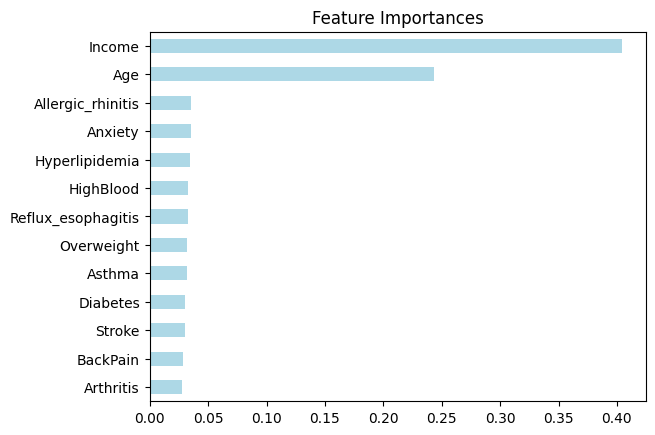

In [ ]:
importances_rf = pd.Series(rf.feature_importances_, index = X.columns)
sorted_importances_rf = importances_rf.sort_values()
sorted_importances_rf.plot(kind='barh', color='lightblue',)
plt.title('Feature Importances')
plt.savefig('Feature Importances.png',bbox_inches='tight')
plt.show()

In [ ]:
importances_rf = pd.DataFrame({'importance': rf.feature_importances_, 'feature':X.columns})
sorted_importances_rf = importances_rf.sort_values(by='importance', ascending=False)

In [ ]:
# Number of top features to select
features = 12

# Select top N features
selected_features = sorted_importances_rf.head(features)['feature']
print(selected_features)

12                Income
11                   Age
8      Allergic_rhinitis
7                Anxiety
5         Hyperlipidemia
0              HighBlood
9     Reflux_esophagitis
2             Overweight
10                Asthma
4               Diabetes
1                 Stroke
6               BackPain
Name: feature, dtype: object


In [ ]:
features_reduced = selected_features.tolist()
print("Reduced Features :", features_reduced)

Reduced Features : ['Income', 'Age', 'Allergic_rhinitis', 'Anxiety', 'Hyperlipidemia', 'HighBlood', 'Reflux_esophagitis', 'Overweight', 'Asthma', 'Diabetes', 'Stroke', 'BackPain']


In [ ]:
# Descriptive Statistics - categorical variables
cat_features = ['Allergic_rhinitis', 'Anxiety', 'Hyperlipidemia', 'HighBlood', 'Reflux_esophagitis', 'Overweight', 'Asthma', 'Diabetes', 'Stroke', 'BackPain']

print("Mean of each categorical feature:")
# Create a for loop to output percentage distribution for each categorical variable
for var in cat_features:
    print(var, ":", df_cleaned[var].mean()*100, "%")

Mean of each categorical feature:
Allergic_rhinitis : 39.410000000000004 %
Anxiety : 32.15 %
Hyperlipidemia : 33.72 %
HighBlood : 40.9 %
Reflux_esophagitis : 41.349999999999994 %
Overweight : 70.94 %
Asthma : 28.93 %
Diabetes : 27.38 %
Stroke : 19.93 %
BackPain : 41.14 %


In [ ]:
# Create a for loop to output the frequency for each categorical variable
for var in cat_features:
    print(df_cleaned[var].describe())

count    10000.000000
mean         0.394100
std          0.488681
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: Allergic_rhinitis, dtype: float64
count    10000.000000
mean         0.321500
std          0.467076
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: Anxiety, dtype: float64
count    10000.000000
mean         0.337200
std          0.472777
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: Hyperlipidemia, dtype: float64
count    10000.000000
mean         0.409000
std          0.491674
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: HighBlood, dtype: float64
count    10000.000000
mean         0.413500
std          0.492486
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max

In [ ]:
# Descriptive Statistics - numeric variables
num_features = df_cleaned[['Age','Income']]

print(pd.DataFrame(num_features).median())
print(pd.DataFrame(num_features).describe())

Age          53.00
Income    33768.42
dtype: float64
                Age         Income
count  10000.000000   10000.000000
mean      53.511700   40490.495160
std       20.638538   28521.153293
min       18.000000     154.080000
25%       36.000000   19598.775000
50%       53.000000   33768.420000
75%       71.000000   54296.402500
max       89.000000  207249.100000


In [ ]:
# Descriptive Statistics - target variable
print('Initial_days median: ', df_cleaned['Initial_days'].median())
df_cleaned['Initial_days'].describe()

Initial_days median:  35.83624435


count    10000.000000
mean        34.455299
std         26.309341
min          1.001981
25%          7.896215
50%         35.836244
75%         61.161020
max         71.981490
Name: Initial_days, dtype: float64

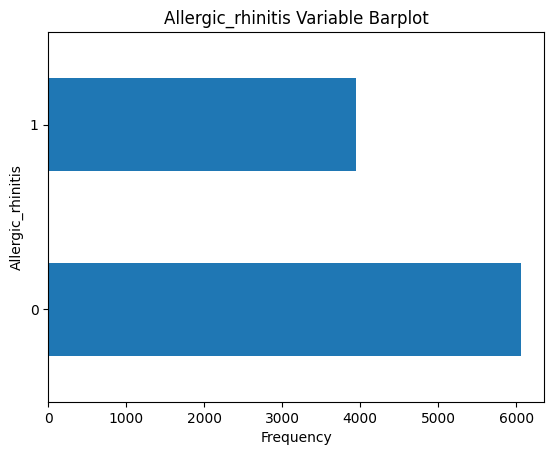

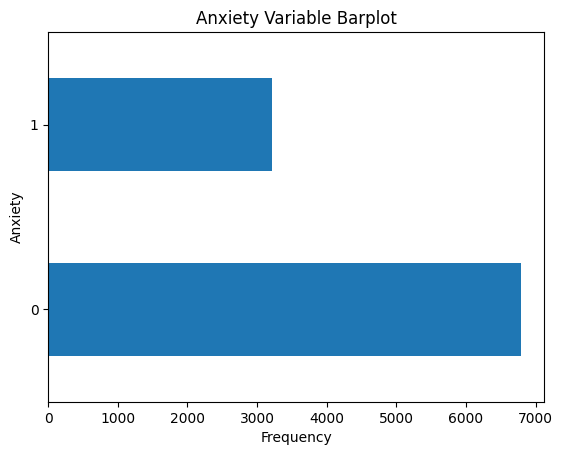

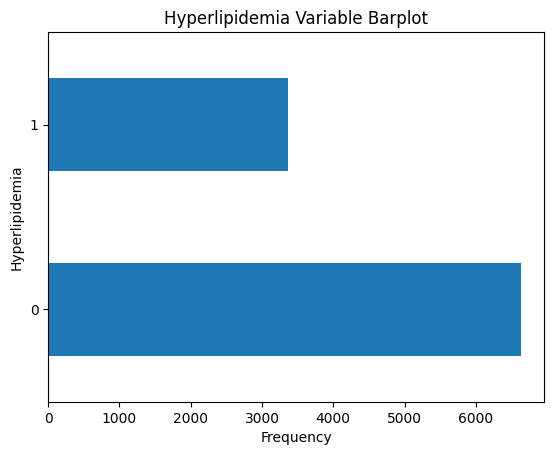

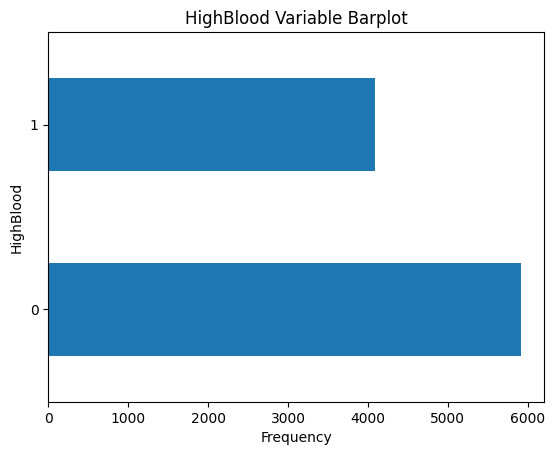

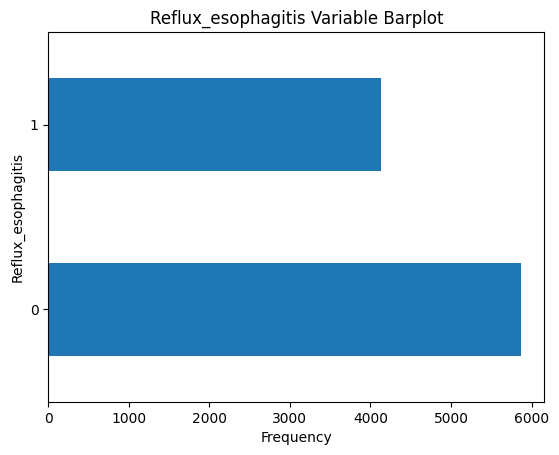

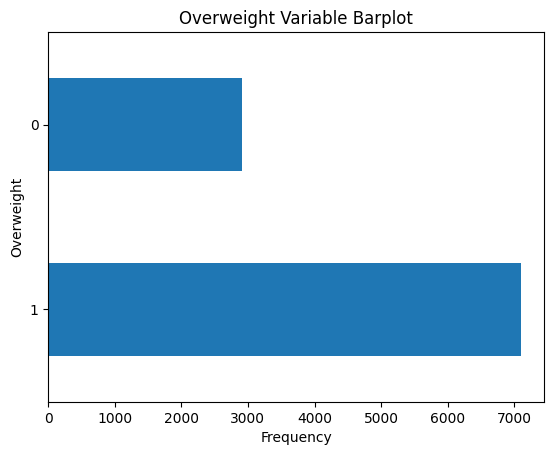

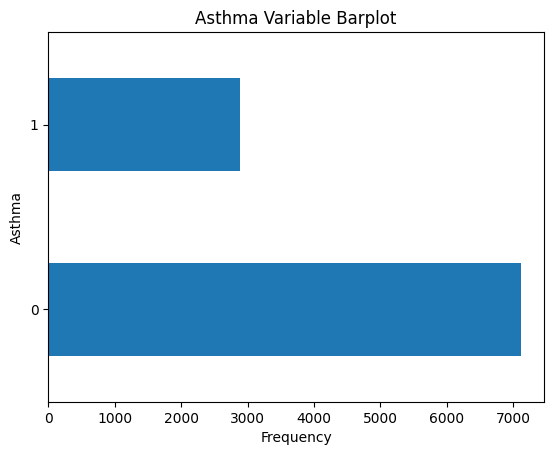

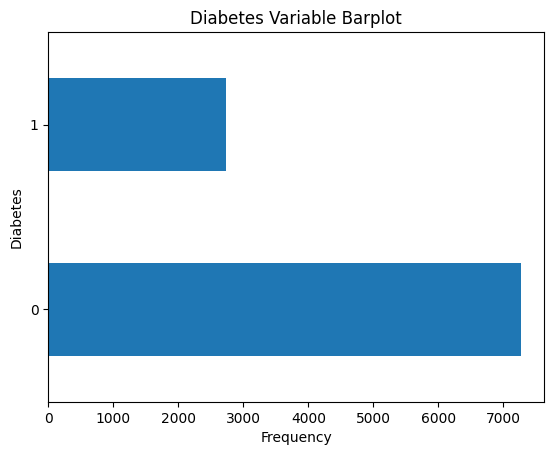

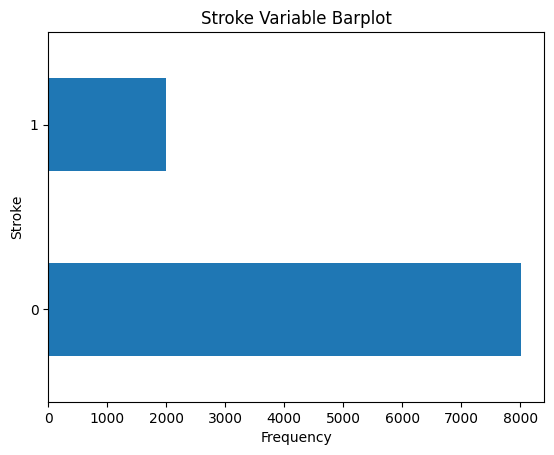

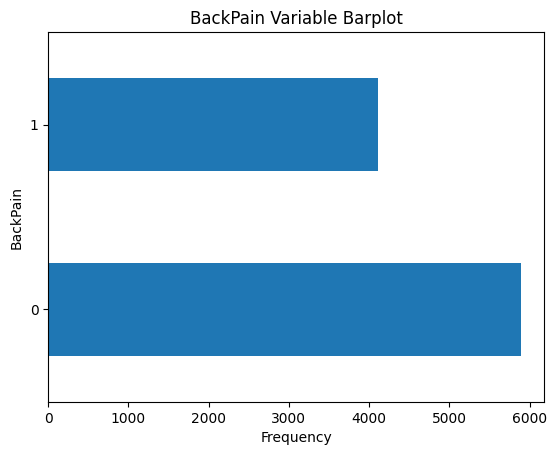

In [ ]:
# Univariate Analysis (visualization) - all categorical variables
# Bar plots are used to represent categorical data and display frequency of the data.

# Create a loop to plot each categorical variables on a horizontal bar plot
for var in cat_features:
    df_cleaned[var].value_counts().plot(kind='barh')
    plt.title(var+' Variable Barplot')
    plt.xlabel('Frequency')
    plt.ylabel(var)
    plt.savefig(var+' Variable - Horizontal Barplot.png',bbox_inches='tight')
    plt.show()

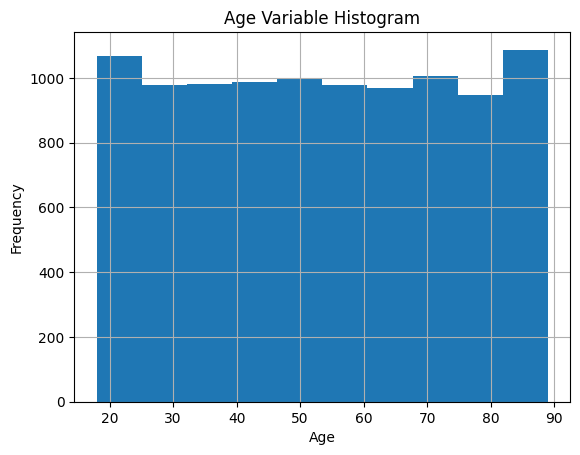

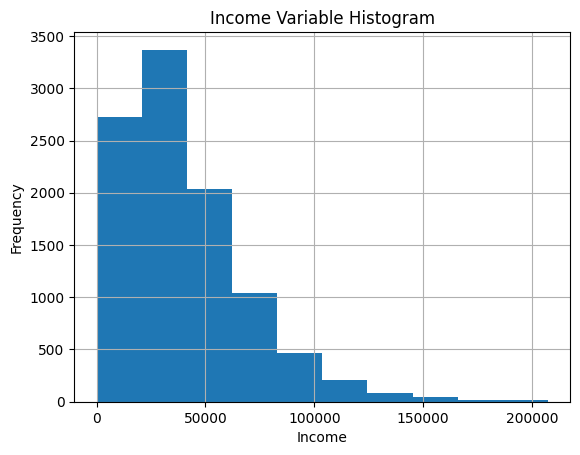

In [ ]:
# Univariate Analysis (visualization) - all numeric variables

# Create a loop to plot each numeric variables on a boxplot
for var in num_features:
    df_cleaned[var].hist()
    plt.title(var+' Variable Histogram')
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.savefig(var+' Variable - Histogram.png',bbox_inches='tight')
    plt.show()

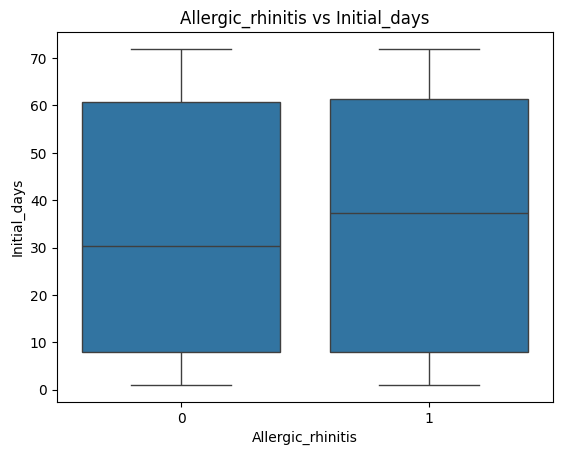

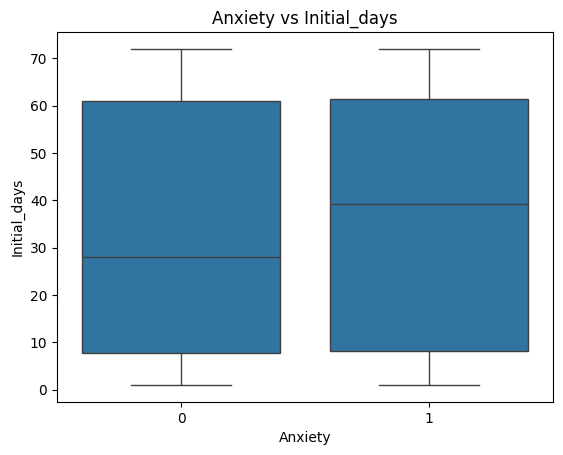

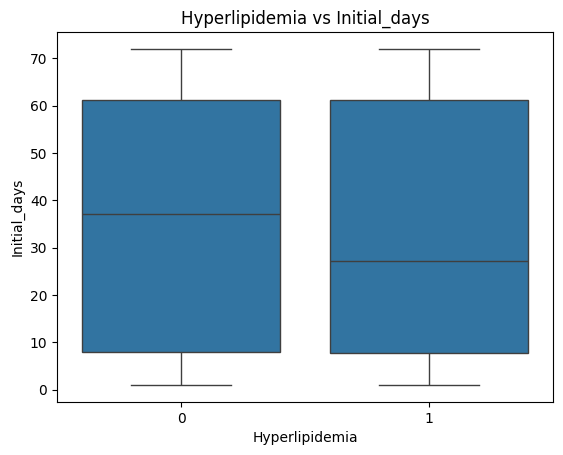

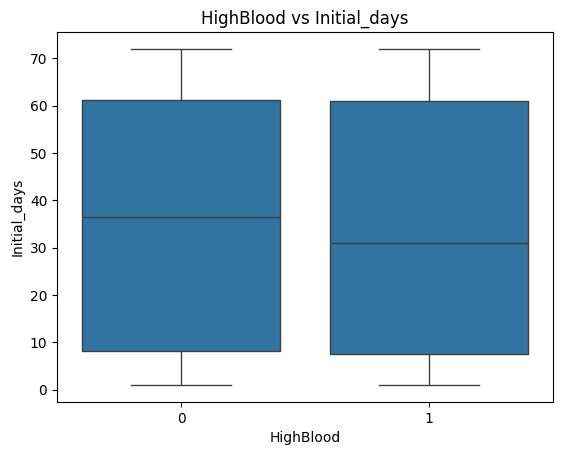

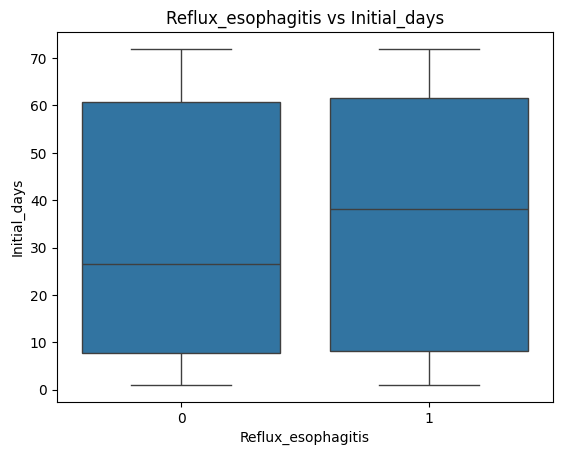

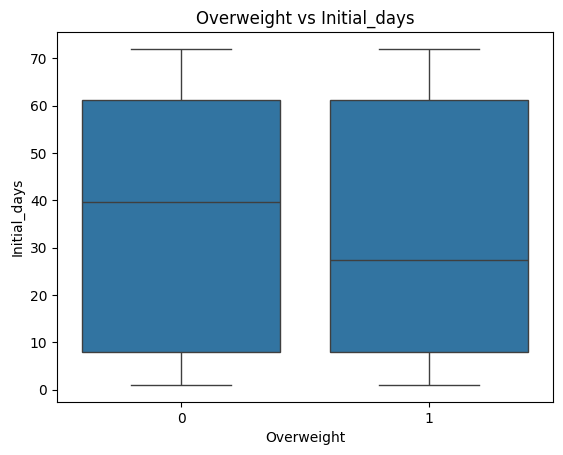

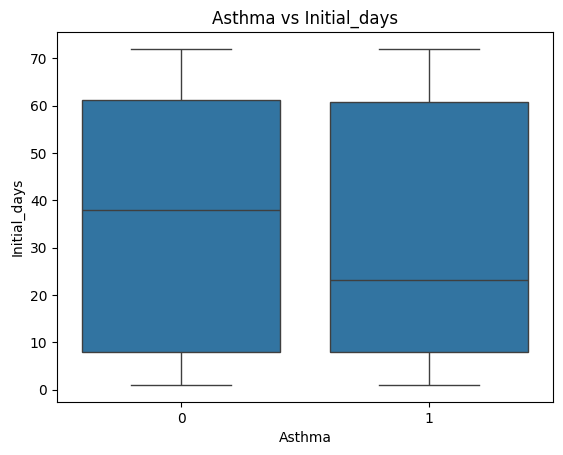

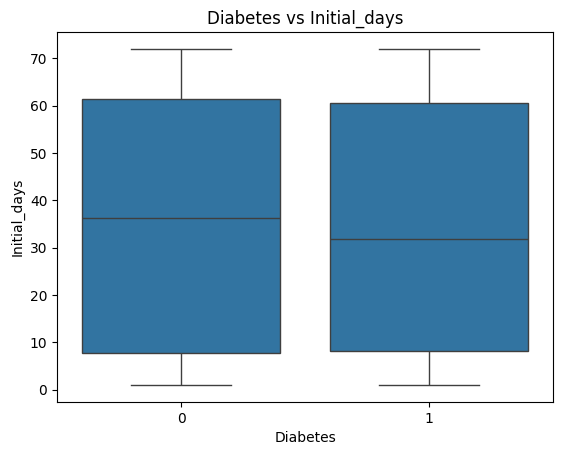

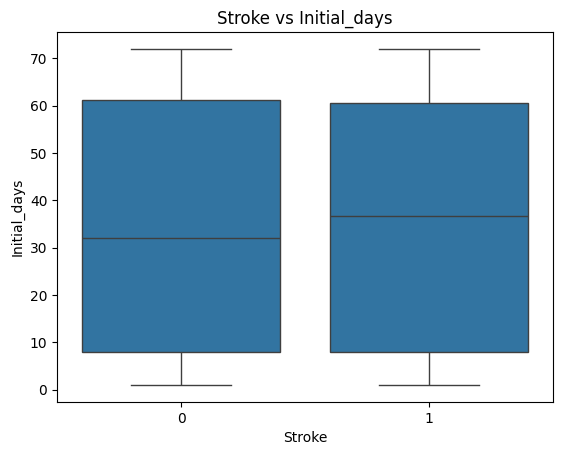

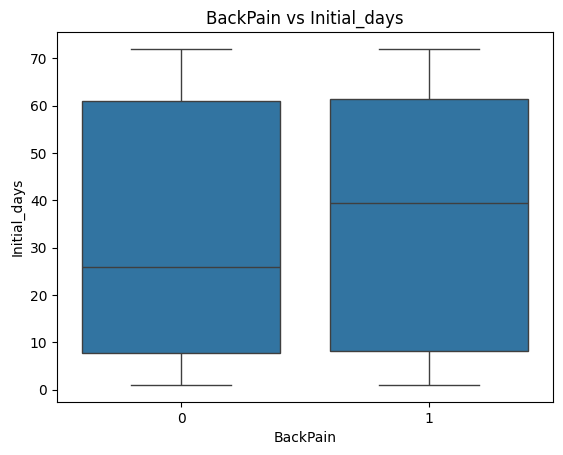

In [ ]:
# Boxplots comparing each categorical variable against the target variable
for var in cat_features:
    sns.boxplot(data=df_cleaned, x=df_cleaned[var], y=df_cleaned['Initial_days'])
    plt.title(var+ ' vs Initial_days')
    plt.savefig(var+ ' vs Initial_days - Boxplot.png')
    plt.show()

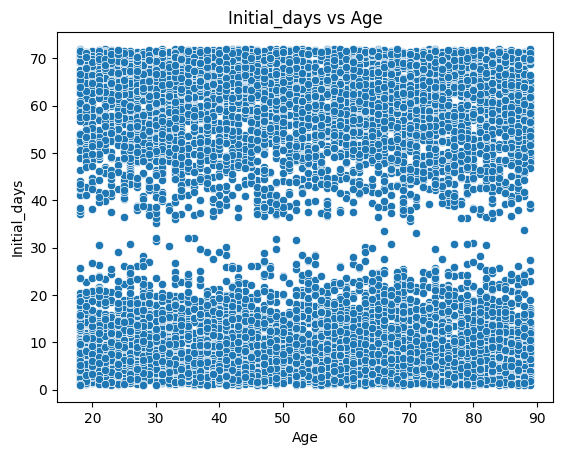

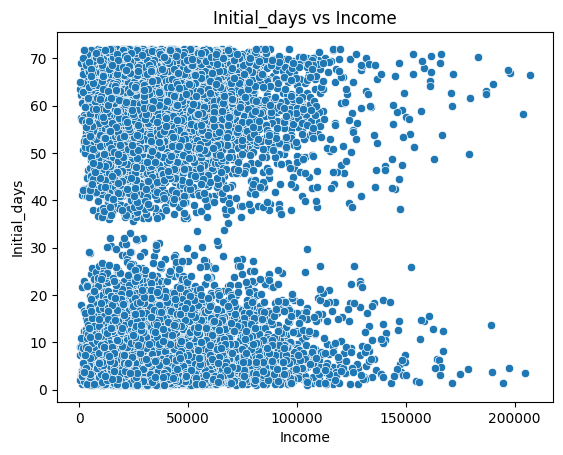

In [ ]:
# Scatterplots comparing each numeric variable against the target variable
for var in num_features:
    sns.scatterplot(data=df_cleaned, x=df_cleaned[var], y=df_cleaned['Initial_days'])
    plt.title('Initial_days vs ' + var)
    plt.savefig('Initial_days vs ' + var +'- Scatterplot.png')
    plt.show()

### C4: CLEANED DATA SET

In [ ]:
# View and export the cleaned data set
df_cleaned = df_cleaned[['Initial_days'] + features_reduced]
df_cleaned.to_csv(r"C:\Users\steph\Documents\GitHub\Data Analysis\7. Data Mining with Random Forest in Python\Outputs\df_cleaned.csv",index=False)
df_cleaned.head()

,Initial_days,Income,Age,Allergic_rhinitis,Anxiety,Hyperlipidemia,HighBlood,Reflux_esophagitis,Overweight,Asthma,Diabetes,Stroke,BackPain
0,10.585770,86575.93,53,1,1,0,1,0,0,1,1,0,1
1,15.129562,46805.99,51,0,0,0,1,1,1,0,0,0,0
2,4.772177,14370.14,53,0,0,0,1,0,1,0,1,0,0
3,1.714879,39741.49,78,0,0,0,0,1,0,1,0,1,0
4,1.254807,1209.56,22,1,0,1,0,0,0,0,0,0,0


### D1: SPLITTING THE DATA

In [ ]:
X = df_cleaned.drop('Initial_days', axis=1)
y = df_cleaned['Initial_days']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45)

print(X_train.shape)
print(X_test.shape)

X_train.info()

(8000, 12)
(2000, 12)
<class 'pandas.core.frame.DataFrame'>
Index: 8000 entries, 4643 to 7115
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Income              8000 non-null   float64
 1   Age                 8000 non-null   int64  
 2   Allergic_rhinitis   8000 non-null   int32  
 3   Anxiety             8000 non-null   int32  
 4   Hyperlipidemia      8000 non-null   int32  
 5   HighBlood           8000 non-null   int32  
 6   Reflux_esophagitis  8000 non-null   int32  
 7   Overweight          8000 non-null   int32  
 8   Asthma              8000 non-null   int32  
 9   Diabetes            8000 non-null   int32  
 10  Stroke              8000 non-null   int32  
 11  BackPain            8000 non-null   int32  
dtypes: float64(1), int32(10), int64(1)
memory usage: 500.0 KB


In [ ]:
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=1)

In [ ]:
# predict the test set labels
y_pred = rf.predict(X_test)
print(y_pred)

[47.18396178 22.15610389 38.71128564 ... 27.58675489 32.01481639
 37.49536532]


In [ ]:
# Export the training and test data set to csv files
pd.DataFrame(X_train).to_csv(r"C:\Users\steph\Documents\GitHub\Data Analysis\7. Data Mining with Random Forest in Python\Outputs\X_train.csv",index=False)
pd.DataFrame(X_test).to_csv(r"C:\Users\steph\Documents\GitHub\Data Analysis\7. Data Mining with Random Forest in Python\Outputs\X_test.csv",index=False)
pd.DataFrame(y_train).to_csv(r"C:\Users\steph\Documents\GitHub\Data Analysis\7. Data Mining with Random Forest in Python\Outputs\y_train.csv",index=False)
pd.DataFrame(y_test).to_csv(r"C:\Users\steph\Documents\GitHub\Data Analysis\7. Data Mining with Random Forest in Python\Outputs\y_test.csv",index=False)

### D2: OUTPUT AND INTERMEDIATE CALCULATIONS

In [ ]:
# define a parameter grid
params = {
          'n_estimators': [100, 200, 300],
          'max_depth': [4,6,8],
          'min_samples_leaf': [1,2,4],
          'max_features': ['log2', 'sqrt']
         }

# create a scorer
mse_scorer = make_scorer(mse, greater_is_better=False)

# perform grid search
grid_mse = GridSearchCV(estimator=rf, param_grid=params, verbose=1, scoring=mse_scorer)

In [ ]:
# fit the random forest regressor to the training set
grid_mse.fit(X_train, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


GridSearchCV(estimator=RandomForestRegressor(random_state=1),
             param_grid={'max_depth': [4, 6, 8],
                         'max_features': ['log2', 'sqrt'],
                         'min_samples_leaf': [1, 2, 4],
                         'n_estimators': [100, 200, 300]},
             scoring=make_scorer(mean_squared_error, greater_is_better=False, response_method='predict'),
             verbose=1)

In [ ]:
# output best parameters
best_hyperparams = grid_mse.best_params_
print('Best hyperparameters:\n', best_hyperparams)

Best hyperparameters:
 {'max_depth': 4, 'max_features': 'log2', 'min_samples_leaf': 4, 'n_estimators': 100}


In [ ]:
# output best score
best_score = grid_mse.best_score_
print('Best score:\n', best_score)

Best score:
 -692.2154424340133


In [ ]:
# extract the best estimator
best_model = grid_mse.best_estimator_
print(best_model)

RandomForestRegressor(max_depth=4, max_features='log2', min_samples_leaf=4,
                      random_state=1)


In [ ]:
# predict the test set labels
y_pred = best_model.predict(X_test)
print(y_pred)

[35.95085716 32.51559354 35.91381067 ... 34.27889045 33.23548813
 34.54445927]


### E1: ACCURACY AND MSE

In [ ]:
test_acc = best_model.score(X_test, y_test)
print('Test accuracy of best model: {:.3f}'.format(test_acc))

Test accuracy of best model: -0.001


In [ ]:
mse_test = mse(y_test, y_pred)
print('Test MSE of best model: {:.3f}'.format(mse_test))

Test MSE of best model: 694.547


In [ ]:
rmse_test = mse_test**(1/2)
print('Test RMSE of best model: {:.3f}'.format(rmse_test))

Test RMSE of best model: 26.354


In [ ]:
r2_score = r2_score(y_test, y_pred)
print('R-squared: {:.3f}'.format(r2_score))

R-squared: -0.001


### E2: RESULTS AND IMPLICATIONS
The model showed zero accuracy, an MSE score of 695, an RMSE score of 26, and an R-squared score of zero, suggesting it performed worse than a mean-based prediction.

### E3: LIMITATION
The dataset's imbalance likely contributed to the poor performance. Future improvements include using balanced data and incorporating more patient information for better context.

### E4: COURSE OF ACTION 
This analysis showcases the importance of feature selection, data balancing, and comprehensive preparation in predictive modeling. Addressing these issues can lead to more accurate predictions, enhancing patient care.